# Analisis exploratorio de resenas

Este notebook descarga un dataset binario de resenas desde Kaggle, normaliza sus columnas y explora la distribucion de las clases `negative` y `positive`.

El CSV descargado debe incluir una columna de texto (`text`, `review` o `Review`) y una columna de etiqueta (`label`, `sentiment` o `rating`).

In [4]:
from pathlib import Path
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

In [5]:
# Dataset publico de Kaggle: instala `kagglehub` antes de ejecutar esta celda.
KAGGLE_DATASET = 'yasserh/imdb-movie-ratings-sentiment-analysis'


def download_kaggle_csv():
    try:
        import kagglehub
    except ImportError as error:
        raise ImportError('Instala kagglehub con `%pip install kagglehub` para descargar el dataset.') from error
    try:
        dataset_dir = Path(kagglehub.dataset_download(KAGGLE_DATASET))
        csv_files = sorted(dataset_dir.rglob('*.csv'))
        if not csv_files:
            raise FileNotFoundError(f'No se encontro ningun CSV en {dataset_dir}')
        print(f'Dataset descargado desde Kaggle: {csv_files[0]}')
        return csv_files[0]
    except Exception as error:
        raise RuntimeError(f'No fue posible descargar el dataset de Kaggle: {error}') from error


DATA_PATH = download_kaggle_csv()

c:\Users\rmerc\Documents\GitHub\sentiment-analysis-movies-reviews\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset descargado desde Kaggle: C:\Users\rmerc\.cache\kagglehub\datasets\yasserh\imdb-movie-ratings-sentiment-analysis\versions\1\movie.csv


## 1. Carga y normalizacion

In [6]:
def normalize_label(value):
    text = str(value).strip().lower()
    if text in {'positive', 'pos', '1', 'true'}:
        return 'positive'
    if text in {'negative', 'neg', '0', 'false'}:
        return 'negative'
    return None


def load_reviews(path=DATA_PATH):
    raw = pd.read_csv(path)
    text_candidates = ['text', 'review', 'Review', 'reviewText', 'Text', 'content', 'body']
    label_candidates = ['label', 'sentiment', 'Sentiment', 'score', 'Score', 'rating', 'overall']
    text_column = next((column for column in text_candidates if column in raw.columns), None)
    label_column = next((column for column in label_candidates if column in raw.columns), None)
    if text_column is None or label_column is None:
        raise ValueError(f'El CSV debe tener texto y etiqueta. Columnas recibidas: {list(raw.columns)}')
    frame = raw[[text_column, label_column]].rename(columns={text_column: 'text', label_column: 'label'})
    frame['label'] = frame['label'].map(normalize_label)
    return frame


reviews = load_reviews()
reviews['text'] = reviews['text'].astype('string').str.replace(r'\s+', ' ', regex=True).str.strip()
reviews = reviews.dropna(subset=['text', 'label']).drop_duplicates(subset='text').reset_index(drop=True)
reviews = reviews[reviews['label'].isin(['negative', 'positive'])].copy()
reviews.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,negative
1,"When I put this movie in my DVD player, and sa...",negative
2,Why do people who do not know what a particula...,negative
3,Even though I have great interest in Biblical ...,negative
4,Im a die hard Dads Army fan and nothing will e...,positive


In [7]:
summary = pd.DataFrame({
    'rows': [len(reviews)],
    'unique_reviews': [reviews['text'].nunique()],
    'missing_text': [reviews['text'].isna().sum()],
    'classes': [reviews['label'].nunique()],
})
summary

,rows,unique_reviews,missing_text,classes
0,39723,39723,0,2


## 2. Distribucion de clases y longitud del texto

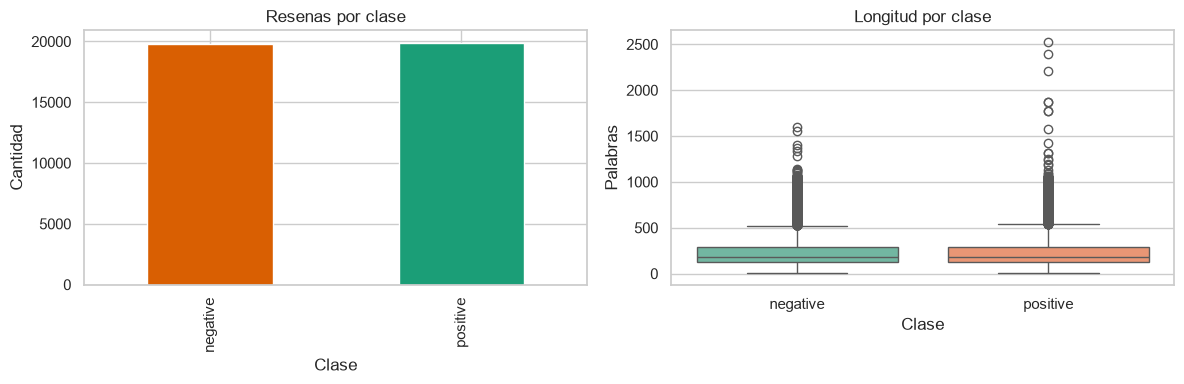

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
negative,19815.0,238.02,170.62,6.0,132.0,181.0,289.0,1598.0
positive,19908.0,241.72,183.81,12.0,129.0,179.0,295.0,2525.0


In [8]:
reviews['word_count'] = reviews['text'].str.findall(r'\b\w+\b').str.len()
class_counts = reviews['label'].value_counts().reindex(['negative', 'positive']).fillna(0)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
class_counts.plot.bar(ax=axes[0], color=['#d95f02', '#1b9e77'], title='Resenas por clase')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Cantidad')
sns.boxplot(data=reviews, x='label', y='word_count', order=['negative', 'positive'], ax=axes[1], palette='Set2', hue='label', legend=False)
axes[1].set_title('Longitud por clase')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Palabras')
plt.tight_layout()
plt.show()

reviews.groupby('label')['word_count'].describe().round(2)

In [9]:
from pathlib import Path
# Save the cleaned dataset to a new CSV file
cleaned_data_path = Path('cleaned_reviews.csv')
reviews.to_csv(cleaned_data_path, index=False)

## Conlcusiones

- El dataset está balanceado con aproximadamente el 50/50 de reseñas positivas y negativas. 
- También se puede observar que la longitud de las reseñas es bastante variable, pero la mayoría de las reseñas tienen menos de 500 palabras. Esto es importante tenerlo en cuenta al momento de entrenar un modelo de NLP, ya que los modelos pueden tener dificultades para manejar textos muy largos o muy cortos.
- Se observa que la longitud de las reseñas positivas tiende a ser mayor que la de las reseñas negativas, lo que podría indicar que los usuarios tienden a escribir más cuando tienen una experiencia positiva con una película. Esto podría ser un factor a considerar al momento de entrenar un modelo de NLP, ya que la longitud del texto podría influir en la predicción de la clase.